# RNN Training + Optuna + ONNX Export for MetaTrader 5

**Что делает ноутбук:**
1. Загружает **normalized .npz** из `artifacts/` (уже нормализованные данные)
2. Optuna подбирает 7 гиперпараметров GRU + порог уверенности
3. Бэктест: WinRate, MaxDD, Profit Factor, Z-Score
4. Score: **PF × WR × (1−DD) × √(trades / (months×3))**
5. Экспортирует лучшие модели в ONNX + RNN_Scaler.mqh

**Структура данных:**
```
artifacts/
  data_BUY_20200102_20260820_normalized.npz  ← 17820 строк, [N, 20, 23]
  data_SELL_20200102_20260820_normalized.npz ← 18903 строк, [N, 20, 23]
```


## Подключение Google Drive и базовые импорты

## 0. Проверка и установка зависимостей

Запускайте эту ячейку первой после каждого нового или перезапущенного Colab runtime. Она проверит окружение, установит отсутствующие пакеты и выведет версии.

In [1]:
# @title 0. Check / Install dependencies
import importlib.util
import subprocess
import sys

required = {
    'optuna': 'optuna',
    'onnx': 'onnx',
    'onnxruntime': 'onnxruntime',
    'onnxscript': 'onnxscript',
}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print('Устанавливаю отсутствующие пакеты:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('Все необходимые пакеты уже установлены.')

import onnx
import onnxruntime
import onnxscript
import optuna

print(f'onnx:       {onnx.__version__}')
print(f'onnxruntime: {onnxruntime.__version__}')
print(f'onnxscript:  {getattr(onnxscript, "__version__", "installed")}')
print(f'optuna:      {optuna.__version__}')
print('Зависимости готовы. Можно запускать ячейку 1 Setup.')


Устанавливаю отсутствующие пакеты: optuna, onnx, onnxruntime, onnxscript
onnx:       1.22.0
onnxruntime: 1.29.0
onnxscript:  0.7.1
optuna:      4.9.0
Зависимости готовы. Можно запускать ячейку 1 Setup.


In [2]:
# @title 1. Mount Drive + install dependencies
import os, sys, glob, math, warnings, io, json
from pathlib import Path

# --- Install missing packages ---
!pip install optuna onnx onnxruntime -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import onnx

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || echo 'No GPU'


Device: cuda
Tesla T4, 15360 MiB


## 2. Configuration

In [11]:
# @title 2. Paths & Constants

# --- Local artifacts paths (NPZ files) ---
SCRIPT_DIR = Path('.').resolve()
ARTIFACTS_DIR = SCRIPT_DIR / 'artifacts'
OUTPUT_DIR = SCRIPT_DIR / 'output'

# --- Trading parameters (MATCH PrepareData.mq5!) ---
SL_PIPS      = 15.0
TP_PIPS      = 20.0
HOLD_BARS    = 20
INITIAL_CAPITAL = 700.0

# --- Training constants ---
N_FEATURES   = 23       # признаков на бар (из artifacts, совпадает с MQL)
N_BARS       = 20       # бар на вход (из artifacts)
N_CLASSES    = 2        # DEAL / UNDEAL
BATCH_SIZE   = 64

# --- Optuna ---
N_TRIALS     = 10       # число попыток
TRAIN_EPOCHS = 40       # эпох на trial (сокращённый режим)
FINAL_EPOCHS = 70       # эпох для финала

# --- Trades baseline: N months in test x 3 trades/month ---
MIN_TRADES_PER_MONTH = 3

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Artifacts: {ARTIFACTS_DIR}')
print(f'Output:    {OUTPUT_DIR}')


Artifacts: /content/artifacts
Output:    /content/output


## 3. Data Loading

In [5]:
# @title 3. NPZ Data Loader

def load_and_split_npz(filepath, seq_len, eps=1e-6):
    """
    Load pre-normalized .npz file, split 80/20 chronologically.
    NPZ keys: 'X' [N, 20, 23], 'y' [N], 'result' [N], 'datetime' [N]
    Returns: train_loader, test_loader, df_test, seq_len, n_features, num_classes, n_months
    """
    data = np.load(filepath, allow_pickle=True)
    X = data['X'].astype(np.float32)       # [N, 20, 23]
    y = data['y'].astype(int)              # [N] labels
    results = data['result'].astype(np.float64)  # [N]
    datetimes = data['datetime']           # [N]

    n_total = len(X)

    # Use all bars (seq_len <= N_BARS)
    actual_seq = min(seq_len, N_BARS)
    X = X[:, :actual_seq, :]

    # Split chronologically 80/20
    n_train = int(n_total * 0.8)

    X_train, X_test = X[:n_train], X[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]
    results_test = results[n_train:]
    dt_test = datetimes[n_train:]

    # Number of months in test set (for trades baseline)
    n_months = 1
    if len(dt_test) > 1:
        try:
            dt_first = pd.Timestamp(dt_test[0])
            dt_last = pd.Timestamp(dt_test[-1])
            n_months = max(1, math.ceil((dt_last - dt_first).days / 30.44))
        except Exception:
            n_months = 1

    # One-hot encoding
    num_classes = len(np.unique(y))
    y_train_oh = np.eye(num_classes)[y_train]
    y_test_oh  = np.eye(num_classes)[y_test]

    # DataFrame for backtest
    df_test = pd.DataFrame({'_result': results_test})
    df_test['datetime'] = dt_test

    print(f"  {os.path.basename(filepath)}: {n_total} rows, train={n_train}, test={n_total - n_train}")
    print(f"    X shape: {X.shape}, features={X.shape[-1]}, seq_len={actual_seq}, test_months={n_months}")
    print(f"    Classes: {dict(zip(*np.unique(y, return_counts=True)))}")

    # Datasets
    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train_oh))
    test_ds  = TensorDataset(torch.FloatTensor(X_test),  torch.FloatTensor(y_test_oh))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, test_loader, df_test, actual_seq, N_FEATURES, num_classes, n_months


# --- Find NPZ files in artifacts/ ---
buy_npz  = sorted(glob.glob(str(ARTIFACTS_DIR / 'data_BUY_*_normalized.npz')))
sell_npz = sorted(glob.glob(str(ARTIFACTS_DIR / 'data_SELL_*_normalized.npz')))

print(f'Artifacts dir: {ARTIFACTS_DIR}')
print(f'BUY:  {[os.path.basename(f) for f in buy_npz]}')
print(f'SELL: {[os.path.basename(f) for f in sell_npz]}')

if not buy_npz or not sell_npz:
    print(f'\nERROR: .npz files not found in {ARTIFACTS_DIR}/')
    raise FileNotFoundError('NPZ files missing')


Artifacts dir: /content/artifacts
BUY:  ['data_BUY_20200102_20260820_normalized.npz']
SELL: ['data_SELL_20200102_20260820_normalized.npz']


## 4. GRU Model

In [6]:
# @title 4. GRU Classifier

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)


## 5. Backtest Engine

In [7]:
# @title 5. Backtest: simulate trades, compute 4 metrics + score

def backtest(model, test_loader, df_test, threshold, n_months, device, initial_capital=700.0):
    """
    Simulate trading chronologically on test set.
    Returns dict: win_rate, max_dd, profit_factor, z_score, n_trades, score, equity, trades.
    Score = PF * WR * (1-DD) * sqrt(trades / baseline)
    baseline = n_months * MIN_TRADES_PER_MONTH
    """
    model.eval()
    all_probs = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            y_pred = model(X_batch.to(device))
            probs = torch.softmax(y_pred, dim=1)[:, 1]  # class DEAL / profitable
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)

    # Simulate trades
    trades = []
    for i, prob in enumerate(all_probs):
        if prob > threshold and i < len(df_test):
            r = df_test.iloc[i]['_result']
            trades.append(float(r))

    n_trades = len(trades)
    if n_trades == 0:
        return {'win_rate': 0.0, 'max_dd': 1.0, 'profit_factor': 0.0,
                'z_score': 0.0, 'n_trades': 0, 'total_return': 0.0,
                'avg_trade': 0.0, 'score': -999.0, 'equity': [], 'trades': []}

    trades = np.array(trades)
    n_wins = int(np.sum(trades > 0))
    win_rate = n_wins / n_trades

    # Equity curve
    equity = initial_capital + np.cumsum(trades)
    equity_full = np.insert(equity, 0, initial_capital)
    peak = np.maximum.accumulate(equity_full)
    dd = (peak - equity_full) / np.maximum(peak, 1e-9)
    max_dd = float(np.max(dd))

    # Profit Factor
    gross_profit  = np.sum(trades[trades > 0])
    gross_loss    = abs(np.sum(trades[trades < 0]))
    profit_factor = float(gross_profit / gross_loss) if gross_loss > 0 else (float('inf') if gross_profit > 0 else 0.0)

    total_return = float(np.sum(trades))
    avg_trade    = total_return / n_trades

    # Z-Score: statistical significance
    if n_trades > 1 and 0 < win_rate < 1:
        z_score = float((win_rate - 0.5) * math.sqrt(n_trades) / math.sqrt(win_rate * (1 - win_rate)))
    else:
        z_score = 0.0

    # SCORE: PF * WR * (1-DD) * sqrt(trades / baseline)
    baseline = max(1, n_months * MIN_TRADES_PER_MONTH)
    pf_clip = min(profit_factor, 10.0)  # cap extreme PF
    score = pf_clip * win_rate * (1.0 - max_dd) * math.sqrt(n_trades / baseline)

    return {
        'win_rate':      win_rate,
        'max_dd':        max_dd,
        'profit_factor': profit_factor,
        'z_score':       z_score,
        'n_trades':      n_trades,
        'total_return':  total_return,
        'avg_trade':     avg_trade,
        'score':         score,
        'equity':        equity.tolist(),
        'trades':        trades.tolist(),
    }


def plot_backtest(metrics, title, save_path=None):
    if not metrics.get('equity'):
        print('  No trades to plot.')
        return
    equity = np.array(metrics['equity'])
    equity_full = np.insert(equity, 0, INITIAL_CAPITAL)
    peak = np.maximum.accumulate(equity_full)
    dd = (peak - equity_full) / np.maximum(peak, 1e-9)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax1.plot(equity_full, 'b-', linewidth=1.0, label='Equity')
    ax1.plot(peak, 'g--', linewidth=0.8, alpha=0.7, label='Peak')
    ax1.fill_between(range(len(equity_full)), equity_full, peak, alpha=0.15, color='red')
    ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5)
    ax1.set_ylabel('Equity')
    ax1.set_title(title)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax2.fill_between(range(len(dd)), dd * 100, 0, alpha=0.3, color='red')
    ax2.plot(dd * 100, 'r-', linewidth=0.8)
    ax2.set_ylabel('Drawdown %')
    ax2.set_xlabel('Trade #')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Chart: {save_path}')
    plt.show()


## 6. Training

In [8]:
# @title 6. Train one model

def train_one_model(model, train_loader, epochs, lr, device, verbose=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.1)
    best_acc = 0.0
    best_state = None

    it = tqdm(range(epochs), desc='Train', leave=False) if verbose else range(epochs)
    for epoch in it:
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch.argmax(dim=1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
            correct   += (y_pred.argmax(dim=1) == y_batch.argmax(dim=1)).sum().item()
            total     += X_batch.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total
        scheduler.step()
        if train_acc > best_acc:
            best_acc = train_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if verbose and hasattr(it, 'set_postfix'):
            it.set_postfix({'loss': f'{train_loss:.4f}', 'acc': f'{train_acc:.4f}'})
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_acc, train_loss


## 7. Optuna Optimization

In [12]:
# @title 7. Optuna: optimize hyperparams (resumable)
# Study сохраняется в output/optuna_*/study.db.
# Если процесс прерван — просто перезапусти эту ячейку: Optuna продолжит
# с последнего завершённого trial (уже завершённые не повторяются).

def load_or_create_study(mode_name):
    study_name = f'rnn_{mode_name}'
    optuna_dir = os.path.join(OUTPUT_DIR, f'optuna_{mode_name}')
    os.makedirs(optuna_dir, exist_ok=True)
    storage_path = os.path.join(optuna_dir, 'study.db')
    storage = f'sqlite:///{storage_path}'

    if os.path.exists(storage_path):
        print(f'  Найден сохранённый study: {storage_path}')
        study = optuna.load_study(study_name=study_name, storage=storage)
        done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
        print(f'  Уже завершено trials: {done}')
        return study

    print(f'  Новый study: {storage_path}')
    return optuna.create_study(
        study_name=study_name,
        storage=storage,
        load_if_exists=True,
        direction='maximize',
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5, interval_steps=1),
    )


def run_optuna(npz_path, mode_name, n_trials=10):
    # Run or resume Optuna study for one mode (BUY/SELL)
    study = load_or_create_study(mode_name)

    done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    remaining = n_trials - done
    if remaining <= 0:
        print(f'  {mode_name}: уже {done} trials из {n_trials}. Нечего запускать.')
        return study.best_params, study

    print(f'  {mode_name}: {done}/{n_trials} trials сделано, запускаю ещё {remaining}...')

    def objective(trial):
        # seq_len: сколько баров использовать на вход (<= N_BARS=20)
        seq_len      = trial.suggest_int('seq_len', 3, 20, step=2)          # 3,5,7,...,19
        hidden_size  = trial.suggest_int('hidden_size', 32, 128, step=16)
        num_layers   = trial.suggest_int('num_layers', 1, 3)
        dropout      = trial.suggest_float('dropout', 0.1, 0.4, step=0.05)
        lr           = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        conf_thresh  = trial.suggest_float('conf_threshold', 0.5, 0.95, step=0.1)  # 0.5..0.9

        try:
            train_loader, test_loader, df_test, seq_len_actual, n_features, num_classes, n_months = \
                load_and_split_npz(npz_path, seq_len=seq_len)
        except Exception as e:
            print(f'  Trial {trial.number} FAILED: {e}')
            return -999.0

        model = GRUClassifier(n_features, hidden_size, num_layers, num_classes, dropout)
        model, train_acc, _ = train_one_model(model, train_loader, TRAIN_EPOCHS, lr, DEVICE, verbose=False)
        metrics = backtest(model, test_loader, df_test, conf_thresh, n_months, DEVICE, INITIAL_CAPITAL)

        trial.report(metrics['score'], step=TRAIN_EPOCHS)
        if trial.should_prune():
            raise optuna.TrialPruned()

        print(f'  T{trial.number:3d} | s={seq_len} h={hidden_size} L={num_layers} '
              f'dr={dropout:.2f} lr={lr:.5f} th={conf_thresh:.2f} | '
              f"WR={metrics['win_rate']:.3f} DD={metrics['max_dd']:.3f} "
              f"PF={metrics['profit_factor']:.2f} Z={metrics['z_score']:.2f} "
              f"N={metrics['n_trades']:4d} score={metrics['score']:.4f}")

        return metrics['score']

    print(f"\n{'='*70}")
    print(f'OPTUNA: {mode_name} | всего {n_trials} trials | score = PF*WR*(1-DD)*sqrt(N/baseline)')
    print(f"{'='*70}")
    study.optimize(objective, n_trials=remaining, show_progress_bar=True)

    print(f'\nBest {mode_name}: score={study.best_value:.4f}')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
    return study.best_params, study


# --- BUY ---
buy_params, buy_study = run_optuna(buy_npz[0], 'BUY', N_TRIALS)

# --- SELL ---
sell_params, sell_study = run_optuna(sell_npz[0], 'SELL', N_TRIALS)


  Найден сохранённый study: /content/output/optuna_BUY/study.db
  Уже завершено trials: 18
  BUY: уже 18 trials из 10. Нечего запускать.
  Новый study: /content/output/optuna_SELL/study.db


[I 2026-08-25 19:42:31,317] A new study created in RDB with name: rnn_SELL


  SELL: 0/10 trials сделано, запускаю ещё 10...

OPTUNA: SELL | всего 10 trials | score = PF*WR*(1-DD)*sqrt(N/baseline)


  0%|          | 0/10 [00:00<?, ?it/s]

  data_SELL_20200102_20260820_normalized.npz: 18903 rows, train=15122, test=3781
    X shape: (18903, 9, 23), features=23, seq_len=9, test_months=16
    Classes: {np.int64(0): np.int64(9932), np.int64(1): np.int64(8971)}
  T  0 | s=9 h=128 L=3 dr=0.30 lr=0.00018 th=0.50 | WR=0.482 DD=1.054 PF=0.94 Z=-0.96 N= 742 score=-0.0958
[I 2026-08-25 19:43:07,339] Trial 0 finished with value: -0.09584054887915382 and parameters: {'seq_len': 9, 'hidden_size': 128, 'num_layers': 3, 'dropout': 0.30000000000000004, 'lr': 0.00018410729205738696, 'conf_threshold': 0.5}. Best is trial 0 with value: -0.09584054887915382.
  data_SELL_20200102_20260820_normalized.npz: 18903 rows, train=15122, test=3781
    X shape: (18903, 3, 23), features=23, seq_len=3, test_months=16
    Classes: {np.int64(0): np.int64(9932), np.int64(1): np.int64(8971)}
  T  1 | s=3 h=128 L=2 dr=0.30 lr=0.00011 th=0.90 | WR=0.000 DD=1.000 PF=0.00 Z=0.00 N=   0 score=-999.0000
[I 2026-08-25 19:43:37,809] Trial 1 finished with value: -999

## 8. Final Training + Backtest


FINAL: BUY | s=9 h=80 L=3 dr=0.35 lr=0.000716 th=0.80
  data_BUY_20200102_20260820_normalized.npz: 17820 rows, train=14256, test=3564
    X shape: (17820, 9, 23), features=23, seq_len=9, test_months=16
    Classes: {np.int64(0): np.int64(9362), np.int64(1): np.int64(8458)}


Train:   0%|          | 0/70 [00:00<?, ?it/s]


  Train Acc: 0.7424, Loss: 0.4857

  BACKTEST BUY (test=16mo, baseline=48 trades):
  ──────────────────────────────────────────────────
  Trades:        488
  Win Rate:      0.5061 (50.6%)
  Max Drawdown:  0.3453 (34.5%)
  Profit Factor: 1.04
  Z-Score:       0.27
  Total Return:  233.55
  Avg Trade:     0.4786
  Score:         1.0994
  ──────────────────────────────────────────────────

FINAL: SELL | s=11 h=112 L=1 dr=0.25 lr=0.001015 th=0.50
  data_SELL_20200102_20260820_normalized.npz: 18903 rows, train=15122, test=3781
    X shape: (18903, 11, 23), features=23, seq_len=11, test_months=16
    Classes: {np.int64(0): np.int64(9932), np.int64(1): np.int64(8971)}


Train:   0%|          | 0/70 [00:00<?, ?it/s]


  Train Acc: 0.9921, Loss: 0.0298

  BACKTEST SELL (test=16mo, baseline=48 trades):
  ──────────────────────────────────────────────────
  Trades:        1693
  Win Rate:      0.4908 (49.1%)
  Max Drawdown:  1.4473 (144.7%)
  Profit Factor: 0.95
  Z-Score:       -0.75
  Total Return:  -1026.79
  Avg Trade:     -0.6065
  Score:         -1.2403
  ──────────────────────────────────────────────────
  Chart: /content/output/buy_backtest.png


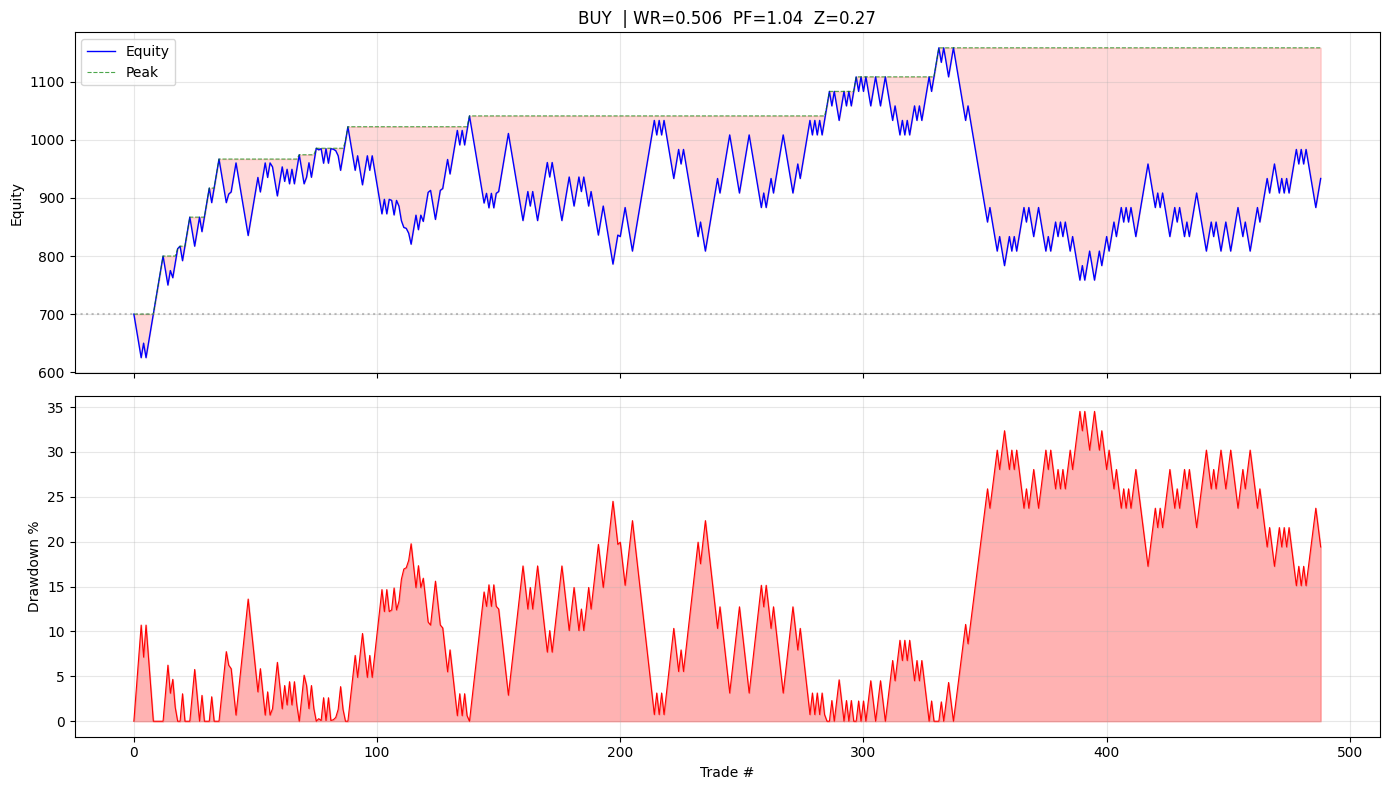

  Chart: /content/output/sell_backtest.png


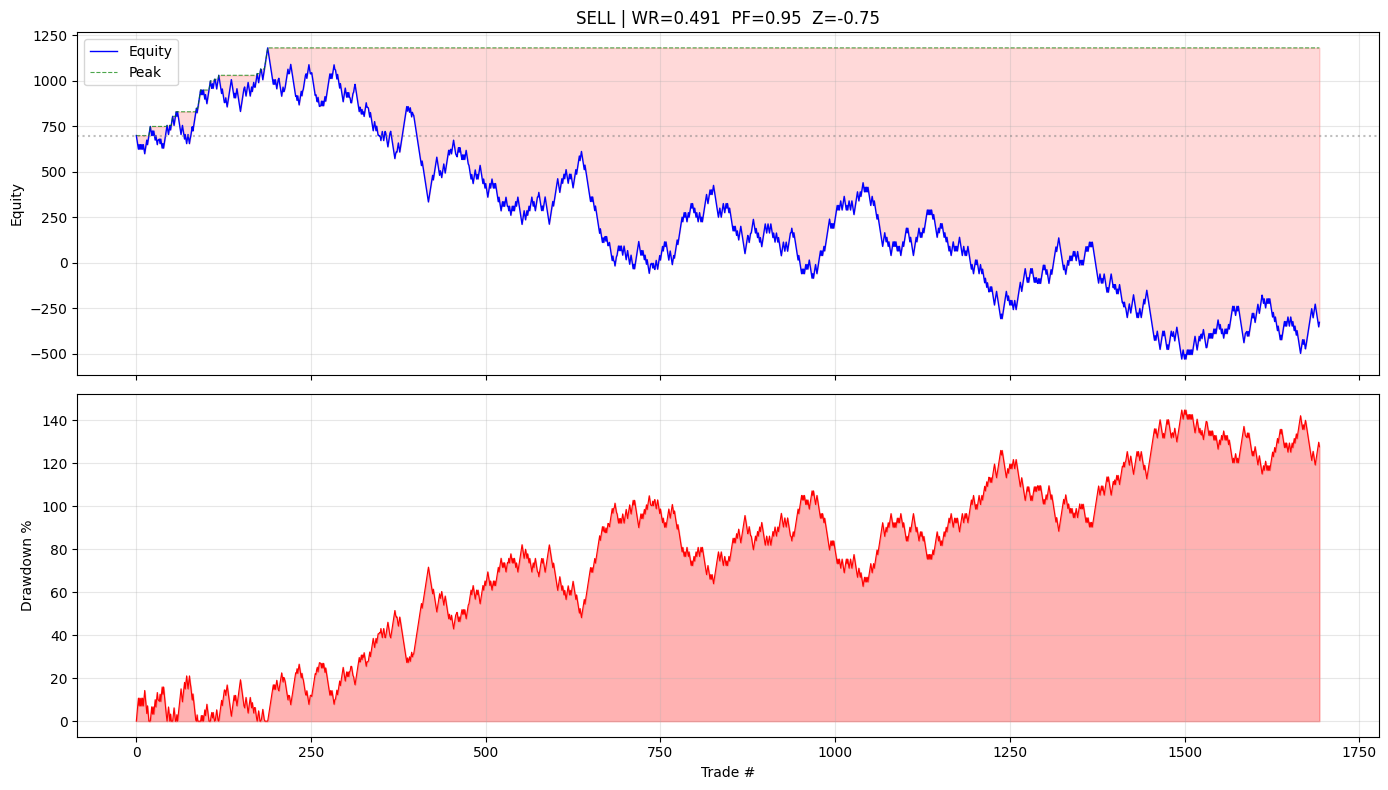

In [13]:
# @title 8. Train best models + backtest

def final_train_and_evaluate(npz_path, params, mode_name):
    seq_len      = params['seq_len']
    hidden_size  = params['hidden_size']
    num_layers   = params['num_layers']
    dropout      = params['dropout']
    lr           = params['lr']
    conf_thresh  = params['conf_threshold']

    print(f"\n{'='*70}")
    print(f"FINAL: {mode_name} | s={seq_len} h={hidden_size} L={num_layers} dr={dropout:.2f} "
          f"lr={lr:.6f} th={conf_thresh:.2f}")
    print(f"{'='*70}")

    train_loader, test_loader, df_test, seq_len_actual, n_features, num_classes, n_months = \
        load_and_split_npz(npz_path, seq_len=seq_len)

    model = GRUClassifier(n_features, hidden_size, num_layers, num_classes, dropout)
    model, train_acc, train_loss = train_one_model(model, train_loader, FINAL_EPOCHS, lr, DEVICE, verbose=True)
    print(f"\n  Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f}")

    metrics = backtest(model, test_loader, df_test, conf_thresh, n_months, DEVICE, INITIAL_CAPITAL)
    baseline = max(1, n_months * MIN_TRADES_PER_MONTH)

    print(f"\n  BACKTEST {mode_name} (test={n_months}mo, baseline={baseline} trades):")
    print(f"  {'─'*50}")
    print(f"  Trades:        {metrics['n_trades']}")
    print(f"  Win Rate:      {metrics['win_rate']:.4f} ({metrics['win_rate']*100:.1f}%)")
    print(f"  Max Drawdown:  {metrics['max_dd']:.4f} ({metrics['max_dd']*100:.1f}%)")
    print(f"  Profit Factor: {metrics['profit_factor']:.2f}")
    print(f"  Z-Score:       {metrics['z_score']:.2f}" + (' *' if abs(metrics['z_score']) > 2.0 else ''))
    print(f"  Total Return:  {metrics['total_return']:.2f}")
    print(f"  Avg Trade:     {metrics['avg_trade']:.4f}")
    print(f"  Score:         {metrics['score']:.4f}")
    print(f"  {'─'*50}")

    return model, metrics, seq_len, n_features


buy_model,  buy_metrics,  buy_seq_len,  buy_nf  = final_train_and_evaluate(buy_npz[0],  buy_params,  'BUY')
sell_model, sell_metrics, sell_seq_len, sell_nf  = final_train_and_evaluate(sell_npz[0], sell_params, 'SELL')

# --- Plot ---
plot_backtest(buy_metrics,  f'BUY  | WR={buy_metrics["win_rate"]:.3f}  PF={buy_metrics["profit_factor"]:.2f}  Z={buy_metrics["z_score"]:.2f}',
              os.path.join(OUTPUT_DIR, 'buy_backtest.png'))
plot_backtest(sell_metrics, f'SELL | WR={sell_metrics["win_rate"]:.3f}  PF={sell_metrics["profit_factor"]:.2f}  Z={sell_metrics["z_score"]:.2f}',
              os.path.join(OUTPUT_DIR, 'sell_backtest.png'))


## 9. ONNX Export + RNN_Scaler.mqh

In [14]:
# @title 9. Export ONNX + generate MQL config

def export_to_onnx(model, seq_len, n_features, out_path, name):
    """Export to self-contained ONNX (no .data files). Required for OnnxCreateFromBuffer."""
    model.eval()
    model.to('cpu')
    dummy = torch.randn(1, seq_len, n_features)
    tmp = out_path + '.tmp'
    old = sys.stdout
    sys.stdout = io.StringIO()
    try:
        torch.onnx.export(model, dummy, tmp,
                          input_names=['input'], output_names=['output'],
                          dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
                          opset_version=18)
    finally:
        sys.stdout = old
    m = onnx.load(tmp)
    raw_bytes = m.SerializeToString()
    if b'.onnx.data' in raw_bytes:
        raise RuntimeError(f'{name}: external .data reference!')
    with open(out_path, 'wb') as f:
        f.write(raw_bytes)
    for x in (tmp, tmp + '.data', out_path + '.data'):
        if os.path.exists(x): os.remove(x)
    kb = os.path.getsize(out_path) / 1024
    print(f'  {name}: {out_path} ({kb:.1f} KB)')


def generate_scaler_mqh(buy_seq_len, sell_seq_len, n_features, eps, out_path):
    lines = [
        '//+------------------------------------------------------------------+',
        '//|                                              RNN_Scaler.mqh      |',
        '//|   Pre-normalized NPZ input (RNN_gold).                         |',
        '//|   Сгенерировано: Colab.                                        |',
        '//+------------------------------------------------------------------+',
        '#ifndef RNN_SCALER_MQH',
        '#define RNN_SCALER_MQH',
        '',
        f'#define NN_BUY_SEQ_LEN      {buy_seq_len}       // BUY input window',
        f'#define NN_SELL_SEQ_LEN     {sell_seq_len}       // SELL input window',
        f'#define NN_MAX_SEQ_LEN      {max(buy_seq_len, sell_seq_len)}',
        f'#define NN_FEATURES      {n_features}    // признаков на бар',
        f'#define NN_NORM_STD_EPS  {eps:g}         // epsilon',
        '',
        '/* Direction-neutral aliases for existing data preparation tools. */',
        '#define NN_SEQ_LEN     NN_BUY_SEQ_LEN',
        '',
        '#endif // RNN_SCALER_MQH',
        '',
    ]
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))
    print(f'  RNN_Scaler.mqh -> {out_path}')


# --- Both models share the feature count ---
if buy_nf != sell_nf:
    raise ValueError(f'BUY/SELL feature count differs: {buy_nf} vs {sell_nf}')
generate_scaler_mqh(buy_seq_len, sell_seq_len, buy_nf, 1e-6,
                     os.path.join(OUTPUT_DIR, 'RNN_Scaler.mqh'))

# --- Export ONNX ---
onnx_dir = os.path.join(OUTPUT_DIR, 'onnx')
os.makedirs(onnx_dir, exist_ok=True)
export_to_onnx(buy_model,  buy_seq_len,  buy_nf, os.path.join(onnx_dir, 'buy_model.onnx'),  'buy')
export_to_onnx(sell_model, sell_seq_len, sell_nf, os.path.join(onnx_dir, 'sell_model.onnx'), 'sell')


  RNN_Scaler.mqh -> /content/output/RNN_Scaler.mqh
  buy: /content/output/onnx/buy_model.onnx (472.0 KB)
  sell: /content/output/onnx/sell_model.onnx (202.1 KB)


## 10. Save All Artifacts

In [15]:
# @title 10. Save models + summary to Drive

# --- Save .pth ---
models_dir = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(models_dir, exist_ok=True)
torch.save(buy_model.state_dict(),  os.path.join(models_dir, 'model_buy_final.pth'))
torch.save(sell_model.state_dict(), os.path.join(models_dir, 'model_sell_final.pth'))
print(f'Models: {models_dir}/')

# --- Summary JSON ---
def safe(v):
    if isinstance(v, (np.floating,)): return float(v)
    if isinstance(v, (np.integer,)):  return int(v)
    if isinstance(v, np.ndarray):     return v.tolist()
    return v

summary = {
    'buy_metrics':  {k: safe(v) for k, v in buy_metrics.items() if k not in ('equity','trades')},
    'sell_metrics': {k: safe(v) for k, v in sell_metrics.items() if k not in ('equity','trades')},
    'buy_params':   {k: safe(v) for k, v in buy_params.items()},
    'sell_params':  {k: safe(v) for k, v in sell_params.items()},
    'sl_pips':  SL_PIPS,
    'tp_pips':  TP_PIPS,
}
with open(os.path.join(OUTPUT_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=safe)
print(f'Summary: {OUTPUT_DIR}/summary.json')

# --- Final report ---
print(f"\n{'='*70}")
print(f"DONE! Files in: {OUTPUT_DIR}/")
print(f"{'='*70}")
print(f"\nDownload to local MT5:\n")
print(f"  1. {onnx_dir}/buy_model.onnx  -> Common\\Files\\RNN\\buy_model.onnx")
print(f"  2. {onnx_dir}/sell_model.onnx -> Common\\Files\\RNN\\sell_model.onnx")
print(f"  3. {OUTPUT_DIR}/RNN_Scaler.mqh -> MQL5\\Experts\\RNN\\RNN_Scaler.mqh")
print(f"\nBUY:  WR={buy_metrics['win_rate']:.3f} DD={buy_metrics['max_dd']:.3f} PF={buy_metrics['profit_factor']:.2f} Z={buy_metrics['z_score']:.2f} N={buy_metrics['n_trades']}")
print(f"SELL: WR={sell_metrics['win_rate']:.3f} DD={sell_metrics['max_dd']:.3f} PF={sell_metrics['profit_factor']:.2f} Z={sell_metrics['z_score']:.2f} N={sell_metrics['n_trades']}")


Models: /content/output/models/
Summary: /content/output/summary.json

DONE! Files in: /content/output/

Download to local MT5:

  1. /content/output/onnx/buy_model.onnx  -> Common\Files\RNN\buy_model.onnx
  2. /content/output/onnx/sell_model.onnx -> Common\Files\RNN\sell_model.onnx
  3. /content/output/RNN_Scaler.mqh -> MQL5\Experts\RNN\RNN_Scaler.mqh

BUY:  WR=0.506 DD=0.345 PF=1.04 Z=0.27 N=488
SELL: WR=0.491 DD=1.447 PF=0.95 Z=-0.75 N=1693
